# Big Mart Sales Prediction - Data Analysis Pipeline

Este notebook implementa um pipeline completo de análise exploratória, tratamento de dados ausentes e preparação de features para predição de vendas em lojas Big Mart.

## Objetivo
Desenvolver um modelo preditivo robusto para prever as vendas de produtos (`OutletSales`) em diferentes lojas, considerando características do produto, loja e localização.

## 1. Importação de Bibliotecas

As bibliotecas essenciais para análise exploratória, processamento de dados e modelagem de machine learning são importadas abaixo.

In [171]:
#importando
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

## 2. Carregamento e Exploração Inicial dos Dados

O arquivo de treinamento é carregado em um DataFrame Pandas. As primeiras e últimas linhas são examinadas para entender a estrutura dos dados.

In [172]:
#banco de dados
big_mart_train = pd.read_csv("db/Train-Set.csv")
pd.concat([big_mart_train.head(10), big_mart_train.tail(10)])

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType,OutletSales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


## 3. Dimensões e Informações do Dataset

Verificamos as dimensões do dataset (número de linhas e colunas) para entender o tamanho da base de dados. Em seguida, examinamos o tipo de dados de cada coluna, a quantidade de não-nulos e alocação de memória. Isso ajuda a identificar potenciais problemas como valores ausentes e tipos de dados inadequados.

In [173]:
#linhas por coluna
big_mart_train.shape

(8523, 12)

In [174]:
#Obtendo algumas informações sobre o conjunto de dados
big_mart_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ProductID          8523 non-null   str    
 1   Weight             7060 non-null   float64
 2   FatContent         8523 non-null   str    
 3   ProductVisibility  8523 non-null   float64
 4   ProductType        8523 non-null   str    
 5   MRP                8523 non-null   float64
 6   OutletID           8523 non-null   str    
 7   EstablishmentYear  8523 non-null   int64  
 8   OutletSize         6113 non-null   str    
 9   LocationType       8523 non-null   str    
 10  OutletType         8523 non-null   str    
 11  OutletSales        8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


## 4. Detecção de Valores Ausentes

A primeira etapa do tratamento de dados é identificar quais colunas possuem valores ausentes (NaN/null). Esse diagnóstico orientará nossas estratégias de imputação.

In [175]:
#checando valores nulos
big_mart_train.isnull().sum()

ProductID               0
Weight               1463
FatContent              0
ProductVisibility       0
ProductType             0
MRP                     0
OutletID                0
EstablishmentYear       0
OutletSize           2410
LocationType            0
OutletType              0
OutletSales             0
dtype: int64

## 5. Tratamento de Valores Ausentes

### 5.1 Padronização da Coluna FatContent

A coluna `FatContent` possui variações inconsistentes (ex: 'LF', 'low fat', 'Low Fat', 'reg', 'Regular'). Padronizaremos para dois valores distintos: 'Low Fat' e 'Regular'.

In [176]:
# Criamos um dicionário de mapeamento para corrigir os erros
mapeamento_gordura_train = {
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'Low Fat': 'Low Fat',
    'reg': 'Regular',
    'Regular': 'Regular'
}

# Aplicamos a correção na coluna do DataFrame
big_mart_train['FatContent'] = big_mart_train['FatContent'].map(mapeamento_gordura_train)


### 5.2 Imputação de Valores Ausentes em Weight

A coluna `Weight` possui valores ausentes. Utilizamos uma estratégia em duas etapas:
1. **Primeira etapa**: Preencher com a média do peso por `ProductID` (assumindo que cada produto tem peso consistente)
2. **Segunda etapa**: Para produtos que aparecem apenas uma vez e ainda têm NaN, preencher com a média por `ProductType`

In [177]:
# Estratégia: Preencher o peso nulo usando a média do próprio ID do produto
big_mart_train['Weight'] = big_mart_train['Weight'].fillna(big_mart_train.groupby('ProductID')['Weight'].transform('mean'))

# Caso ainda reste algum nulo (produtos que só aparecem uma vez e sem peso),
# preenchemos com a média da categoria (ProductType)
big_mart_train['Weight'] = big_mart_train['Weight'].fillna(big_mart_train.groupby('ProductType')['Weight'].transform('mean'))

## 6. Exploração Detalhada das Colunas

Vamos listar todas as colunas para referência posterior:

### 6.1 Análise de OutletID vs OutletSize

Investigamos se há uma relação consistente entre `OutletID` e `OutletSize`. Cada loja deveria ter um tamanho único, mas há valores ausentes que precisamos preencher inteligentemente.

In [178]:
# --- PASSO 1: Analisar o OutletID ---
# Vamos ver como o OutletSize se distribui para cada ID de loja específico
#quantos id nos temos?
print("--- Antes: Quantidade de OutletIDs distintos ---")
quantidade_outlet_ids = big_mart_train['OutletID'].nunique()

print(f"Quantidade de OutletIDs distintos: {quantidade_outlet_ids}")

print("--- PASSO 1: Distribuição de Tamanhos por OutletID ---")
analise_por_id = pd.crosstab(
    [big_mart_train['OutletID'],], 
    big_mart_train['OutletSize'], 
    dropna=False
)
print(analise_por_id)
print("\n" + "="*50 + "\n")


--- Antes: Quantidade de OutletIDs distintos ---
Quantidade de OutletIDs distintos: 10
--- PASSO 1: Distribuição de Tamanhos por OutletID ---
OutletSize  High  Medium  Small  NaN
OutletID                            
OUT010         0       0      0  555
OUT013       932       0      0    0
OUT017         0       0      0  926
OUT018         0     928      0    0
OUT019         0       0    528    0
OUT027         0     935      0    0
OUT035         0       0    930    0
OUT045         0       0      0  929
OUT046         0       0    930    0
OUT049         0     930      0    0




**Conclusão**: Não é possível usar `OutletID` para identificar univocamente o `OutletSize`. Cada OutletID aparece apenas uma vez no dataset, então usaremos a relação entre `OutletType` e `OutletSize`.

### 6.2 Tipos de Lojas (OutletType)

Verificamos quantos tipos de lojas diferentes existem no dataset:

In [179]:
# --- PASSO 2: Validar o OutletSize 
print("--- Antes: Quantidade de OutletType distintos ---")
quantidade_outlet_sizes = big_mart_train['OutletType'].nunique()
print(f"Quantidade de OutletType distintos: {quantidade_outlet_sizes}")
quantidade_outlet_sizes = big_mart_train['OutletType'].unique()
print(f"OutletType distintos: {quantidade_outlet_sizes}")

--- Antes: Quantidade de OutletType distintos ---
Quantidade de OutletType distintos: 4
OutletType distintos: <StringArray>
['Supermarket Type1', 'Supermarket Type2', 'Grocery Store',
 'Supermarket Type3']
Length: 4, dtype: str


### 6.3 Distribuição de Tamanho de Loja por Tipo de Loja

Analisamos a relação entre `OutletType`, `LocationType` e `OutletSize` para definir regras de imputação:

**Descobertas**: 
- `Grocery Store`: Apenas "Small" (sem valores ausentes após análise)
- `Supermarket Type2`: 100% "Medium"
- `Supermarket Type3`: 100% "Medium"
- `Supermarket Type1`: Distribuição variada (requer análise mais profunda)

In [180]:
# --- para Grocery Store ---

print("--- PASSO 2: Verificando o tamanho das Grocery Stores ---")
grocery_stores = big_mart_train[big_mart_train['OutletType'] == 'Grocery Store']
analise_grocery = pd.crosstab(
    grocery_stores['LocationType'], 
    grocery_stores['OutletSize'], 
    dropna=False
)
print(analise_grocery)
print("\n" + "="*50 + "\n")

# --- para Supermarket Type1 ---

print("--- PASSO 2: Verificando o tamanho das Supermarket Type1 ---")
supermarket_type1 = big_mart_train[big_mart_train['OutletType'] == 'Supermarket Type1']
analise_supermarket_type1 = pd.crosstab(
    supermarket_type1['LocationType'], 
    supermarket_type1['OutletSize'], 
    dropna=False
)
print(analise_supermarket_type1)
print("\n" + "="*50 + "\n")

# --- para Supermarket Type2 ---
print("--- PASSO 2: Verificando o tamanho das Supermarket Type2 ---")
supermarket_type2 = big_mart_train[big_mart_train['OutletType'] == 'Supermarket Type2']
analise_supermarket_type2 = pd.crosstab(
    supermarket_type2['LocationType'], 
    supermarket_type2['OutletSize'], 
    dropna=False
)
print(analise_supermarket_type2)
print("\n" + "="*50 + "\n")

# --- para Supermarket Type3 ---
print("--- PASSO 2: Verificando o tamanho das Supermarket Type3 ---")
supermarket_type3 = big_mart_train[big_mart_train['OutletType'] == 'Supermarket Type3']
analise_supermarket_type3 = pd.crosstab(
    supermarket_type3['LocationType'], 
    supermarket_type3['OutletSize'], 
    dropna=False
)
print(analise_supermarket_type3)
print("\n" + "="*50 + "\n")

--- PASSO 2: Verificando o tamanho das Grocery Stores ---
OutletSize    Small  NaN
LocationType            
Tier 1          528    0
Tier 3            0  555


--- PASSO 2: Verificando o tamanho das Supermarket Type1 ---
OutletSize    High  Medium  Small   NaN
LocationType                           
Tier 1           0     930    930     0
Tier 2           0       0    930  1855
Tier 3         932       0      0     0


--- PASSO 2: Verificando o tamanho das Supermarket Type2 ---
OutletSize    Medium
LocationType        
Tier 3           928


--- PASSO 2: Verificando o tamanho das Supermarket Type3 ---
OutletSize    Medium
LocationType        
Tier 3           935




### 6.4 Análise Consolidada: Padrão Geral de Distribuição

Consolidamos a análise para entender o padrão geral de distribuição entre tipos de loja e tipos de localização:

In [181]:
#como Grocery Stores apresentou somente small e nan vamos considar tudo como small e como podemos ver tambem Supermarket Type2 é 100% medium e o Supermarket Type3 é 100% Medium,
# entao vamos avaliar mais profundamente o que fazer com os nulos de OutletSize que sao exclusimante do Supermarket Type1
print("--- PASSO 3: Padrão Geral de Distribuição (Tipo vs Localização) ---")
analise_padrao = pd.crosstab(
    [big_mart_train['OutletType'],
     big_mart_train['LocationType']],
    big_mart_train['OutletSize'],
    dropna=False
)
print(analise_padrao)


--- PASSO 3: Padrão Geral de Distribuição (Tipo vs Localização) ---
OutletSize                      High  Medium  Small   NaN
OutletType        LocationType                           
Grocery Store     Tier 1           0       0    528     0
                  Tier 2           0       0      0     0
                  Tier 3           0       0      0   555
Supermarket Type1 Tier 1           0     930    930     0
                  Tier 2           0       0    930  1855
                  Tier 3         932       0      0     0
Supermarket Type2 Tier 1           0       0      0     0
                  Tier 2           0       0      0     0
                  Tier 3           0     928      0     0
Supermarket Type3 Tier 1           0       0      0     0
                  Tier 2           0       0      0     0
                  Tier 3           0     935      0     0


In [182]:
# Agora vamos preencher os valores nulos de OutletSize usando a moda por OutletType
moda_por_outlet_type_train = (
    big_mart_train.groupby('OutletType')
    ['OutletSize']
    .apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

big_mart_train['OutletSize'] = big_mart_train['OutletSize'].fillna(big_mart_train['OutletType'].map(moda_por_outlet_type_train))

In [183]:
print(moda_por_outlet_type_train)

OutletType
Grocery Store         Small
Supermarket Type1     Small
Supermarket Type2    Medium
Supermarket Type3    Medium
Name: OutletSize, dtype: str


## 7. Visualizando graficos

Esta seção transforma o dataset em sinais visuais para validar hipóteses de negócio e identificar padrões de distribuição antes da modelagem. Os gráficos ajudam a verificar assimetria, presença de outliers, comportamento de variáveis numéricas e a distribuição de categorias importantes.

In [184]:
sns.set()

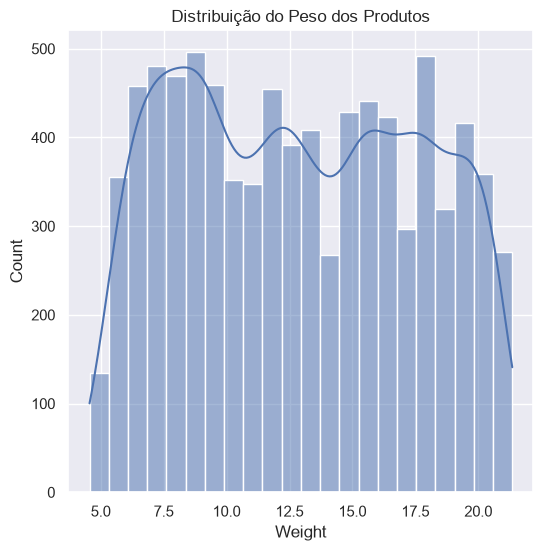

In [185]:
# Distribuição do peso dos produtos para avaliar simetria e possíveis valores extremos
plt.figure(figsize=(6, 6))
sns.histplot(big_mart_train['Weight'], kde=True)
plt.title('Distribuição do Peso dos Produtos')
plt.show()

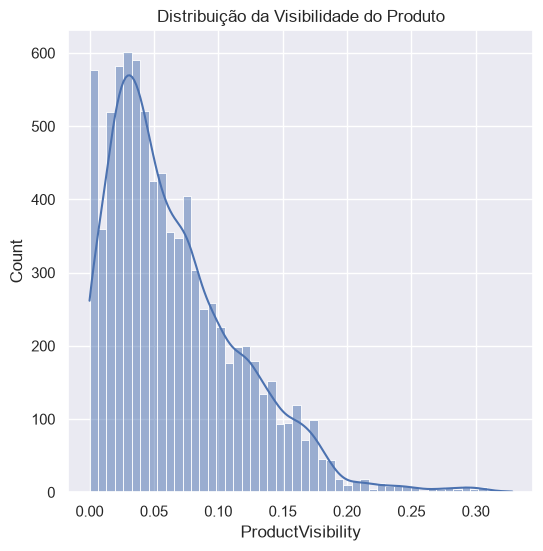

In [186]:
# Distribuição da visibilidade do produto para entender o comportamento das categorias nas prateleiras
plt.figure(figsize=(6, 6))
sns.histplot(big_mart_train['ProductVisibility'], kde=True)
plt.title('Distribuição da Visibilidade do Produto')
plt.show()

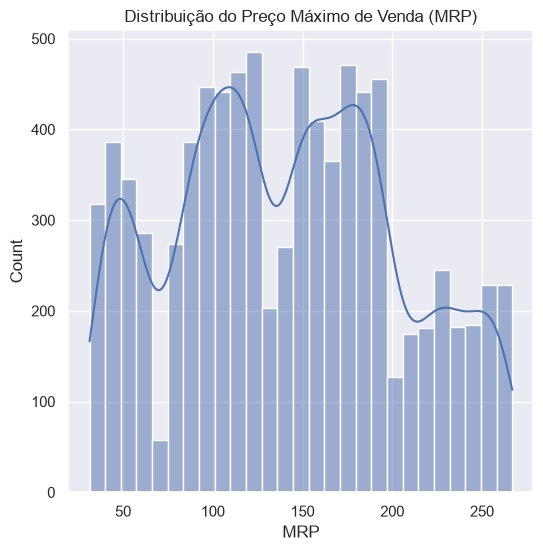

In [187]:
# Distribuição do preço máximo de venda (MRP) para verificar a escala e possíveis assimetrias
plt.figure(figsize=(6, 6))
sns.histplot(big_mart_train['MRP'], kde=True)
plt.title('Distribuição do Preço Máximo de Venda (MRP)')
plt.show()

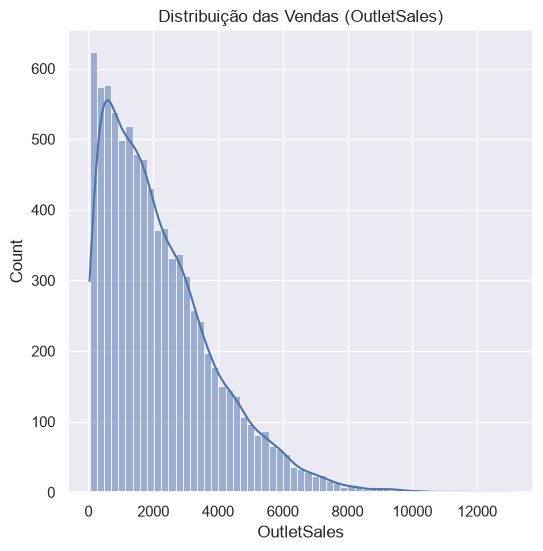

In [188]:
# Distribuição da variável alvo para analisar o comportamento das vendas e a presença de valores extremos
plt.figure(figsize=(6, 6))
sns.histplot(big_mart_train['OutletSales'], kde=True)
plt.title('Distribuição das Vendas (OutletSales)')
plt.show()

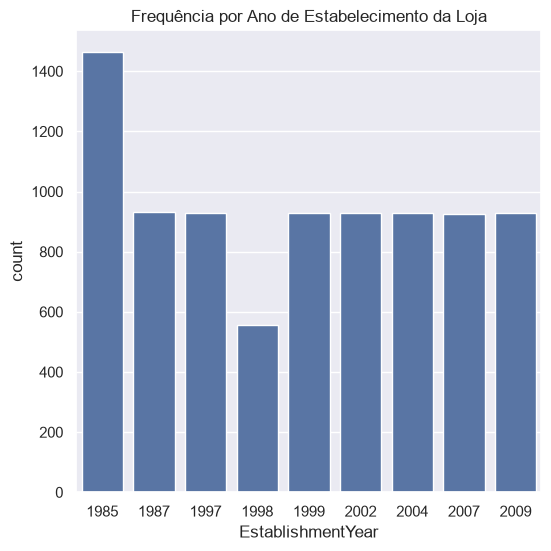

In [189]:
# Frequência do ano de estabelecimento das lojas para verificar a distribuição temporal da base
plt.figure(figsize=(6, 6))
sns.countplot(x='EstablishmentYear', data=big_mart_train)
plt.title('Frequência por Ano de Estabelecimento da Loja')
plt.show()

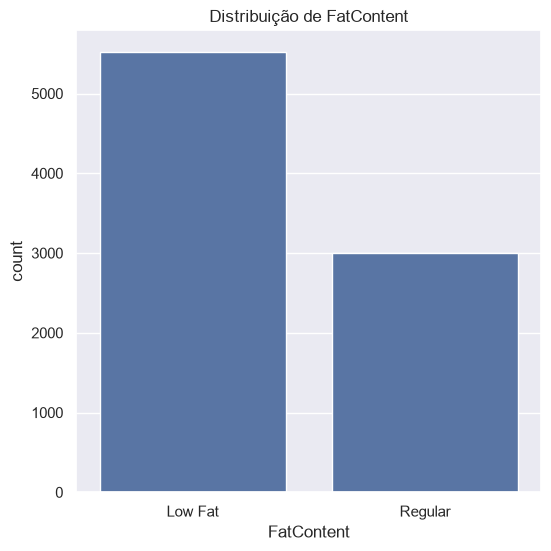

In [190]:
# Frequência das categorias de gordura para validar a consistência da variável após o tratamento
plt.figure(figsize=(6, 6))
sns.countplot(x='FatContent', data=big_mart_train)
plt.title('Distribuição de FatContent')
plt.show()

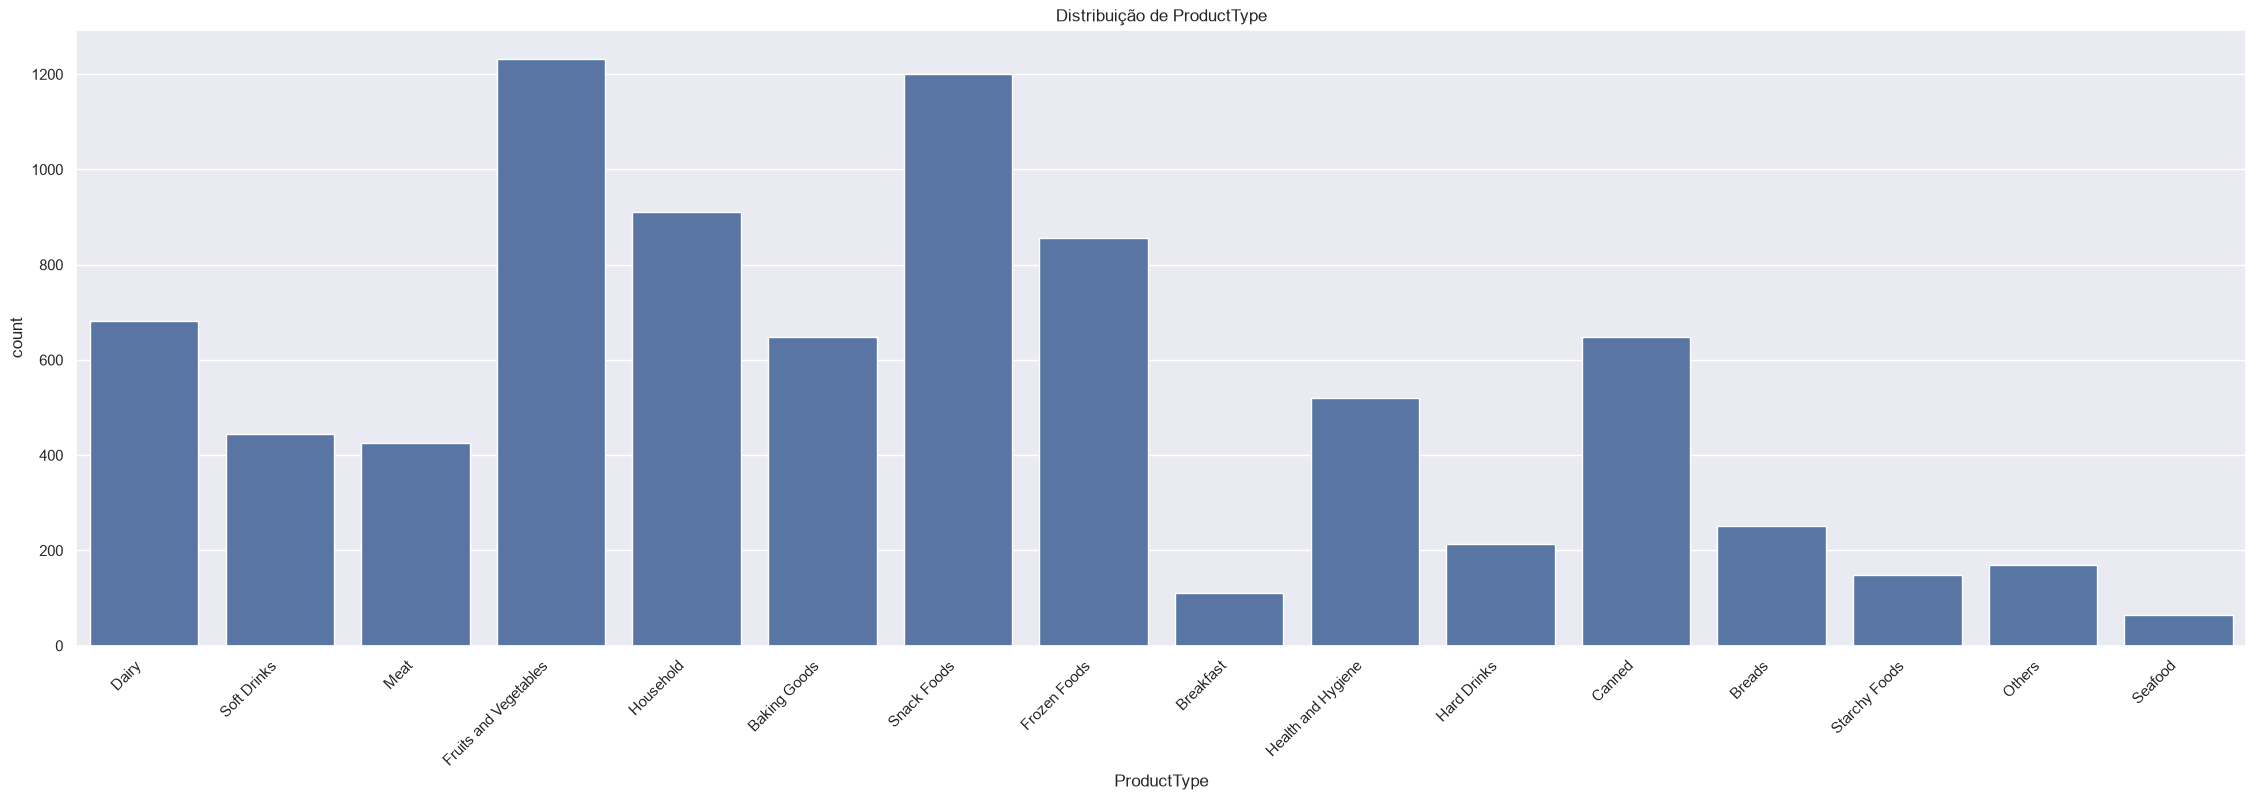

In [191]:
# Frequência dos tipos de produto para identificar categorias mais recorrentes na base
plt.figure(figsize=(28, 8))
sns.countplot(x='ProductType', data=big_mart_train)
plt.title('Distribuição de ProductType')
plt.xticks(rotation=45, ha='right')
plt.show()

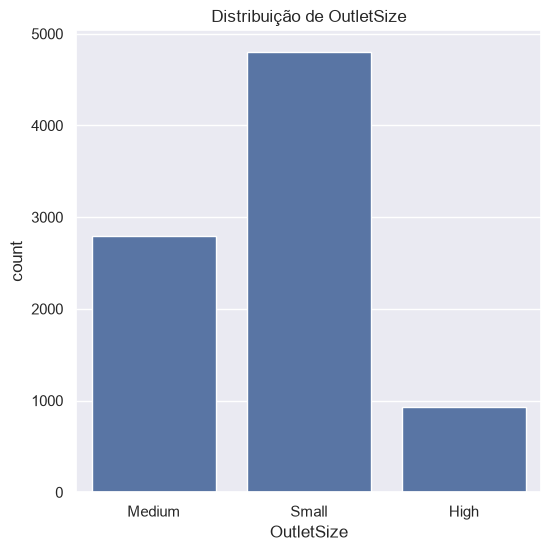

In [192]:
# Frequência do tamanho das lojas para avaliar a composição da rede e a qualidade da imputação
plt.figure(figsize=(6, 6))
sns.countplot(x='OutletSize', data=big_mart_train)
plt.title('Distribuição de OutletSize')
plt.show()

## 8. Machine Learning

Nesta seção, organizamos o fluxo de preparação, treinamento, avaliação e geração de previsões para o modelo preditivo.

### 8.1 Preparação do Encoder

Inicialmente, criamos um encoder para transformar as variáveis categóricas em valores numéricos, o que é necessário para o modelo de regressão.

In [ ]:
# Criamos um encoder para transformar as variáveis categóricas em valores numéricos
encoder = LabelEncoder()

# Aplicamos a transformação em cada coluna categórica relevante
big_mart_train['FatContent'] = encoder.fit_transform(big_mart_train['FatContent'])
big_mart_train['ProductType'] = encoder.fit_transform(big_mart_train['ProductType'])
big_mart_train['OutletSize'] = encoder.fit_transform(big_mart_train['OutletSize'])
big_mart_train['LocationType'] = encoder.fit_transform(big_mart_train['LocationType'])
big_mart_train['OutletType'] = encoder.fit_transform(big_mart_train['OutletType'])
big_mart_train['OutletID'] = encoder.fit_transform(big_mart_train['OutletID'])
big_mart_train['ProductID'] = encoder.fit_transform(big_mart_train['ProductID'])

### 8.2 Visualização da Base Preparada

A seguir, verificamos a aparência do dataset já transformado antes de definir as variáveis de entrada e saída.

In [ ]:
big_mart_train.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType,OutletSales
0,156,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.20,1,0.000000,6,182.0950,0,1998,2,2,0,732.3800
4,1297,8.93,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052


### 8.3 Definição de Variáveis de Entrada e Alvo

Separaremos as colunas que servirão como características do modelo e a variável alvo, que é o valor de vendas a ser previsto.

In [ ]:
x = big_mart_train.drop('OutletSales', axis = 1)
y = big_mart_train["OutletSales"]

In [197]:
print(x)

      ProductID  Weight  FatContent  ProductVisibility  ProductType       MRP  \
0           156   9.300           0           0.016047            4  249.8092   
1             8   5.920           1           0.019278           14   48.2692   
2           662  17.500           0           0.016760           10  141.6180   
3          1121  19.200           1           0.000000            6  182.0950   
4          1297   8.930           0           0.000000            9   53.8614   
...         ...     ...         ...                ...          ...       ...   
8518        370   6.865           0           0.056783           13  214.5218   
8519        897   8.380           1           0.046982            0  108.1570   
8520       1357  10.600           0           0.035186            8   85.1224   
8521        681   7.210           1           0.145221           13  103.1332   
8522         50  14.800           0           0.044878           14   75.4670   

      OutletID  Establishme

In [198]:
print(y)

0       3735.1380
1        443.4228
2       2097.2700
3        732.3800
4        994.7052
          ...    
8518    2778.3834
8519     549.2850
8520    1193.1136
8521    1845.5976
8522     765.6700
Name: OutletSales, Length: 8523, dtype: float64


### 8.4 Divisão Treino/Teste

Antes de treinar o modelo, separamos os dados em conjunto de treino e teste para avaliar a generalização do algoritmo.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)
print(x.shape, x_train.shape, x_test.shape)

(8523, 11) (6818, 11) (1705, 11)


### 8.5 Modelo XGBoost Regressor

Utilizamos um regressor XGBoost para aprender o padrão entre as características e as vendas observadas.

In [ ]:
# Instanciamos o modelo com parâmetros básicos para treinamento inicial
model = XGBRegressor(n_estimators=750, learning_rate=0.007)

In [ ]:
# Treinamos o modelo com os dados de treino
model.fit(x_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### 8.6 Avaliação do Modelo

Calculamos métricas de desempenho para verificar quão bem o modelo explica os dados de treino e de teste.

In [ ]:
# Fazemos a predição para os dados de treino
train_data_prediction = model.predict(x_train)

In [ ]:
# Calculamos o coeficiente de determinação para os dados de treino
r2_train = metrics.r2_score(y_train, train_data_prediction)
print("R Squared Value : ", r2_train)

R Squared Value :  0.6896170923739625


In [ ]:
# Fazemos a predição para os dados de teste
test_data_prediction = model.predict(x_test)

In [ ]:
# Calculamos o coeficiente de determinação para os dados de teste
r2_test = metrics.r2_score(y_test, test_data_prediction)
print("R Squared Value : ", r2_test)

R Squared Value :  0.5780952672660324


### 8.7 Previsão para Dados de Teste

Agora aplicamos o modelo treinado a um conjunto sem rótulo para gerar as previsões de vendas.

In [ ]:
# Carregamos o conjunto de teste para gerar as previsões
big_mart_test = pd.read_csv("db/Test-Set.csv")
big_mart_test.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [207]:
big_mart_test.shape

(5681, 11)

In [208]:
big_mart_test.isnull().sum()

ProductID               0
Weight                976
FatContent              0
ProductVisibility       0
ProductType             0
MRP                     0
OutletID                0
EstablishmentYear       0
OutletSize           1606
LocationType            0
OutletType              0
dtype: int64

In [209]:
# Criamos um dicionário de mapeamento para corrigir os erros
mapeamento_gordura_test = {
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'Low Fat': 'Low Fat',
    'reg': 'Regular',
    'Regular': 'Regular'
}

# Aplicamos a correção na coluna do DataFrame
big_mart_test['FatContent'] = big_mart_test['FatContent'].map(mapeamento_gordura_test)


### 8.8 Tratamento de Dados de Teste

Repetimos o mesmo processo de limpeza e transformação para garantir que os dados de teste estejam compatíveis com o treino.

In [ ]:
# Estratégia: preencher o peso nulo usando a média do próprio ID do produto
big_mart_test['Weight'] = big_mart_test['Weight'].fillna(big_mart_test.groupby('ProductID')['Weight'].transform('mean'))

# Caso ainda reste algum nulo, preenchemos com a média da categoria (ProductType)
big_mart_test['Weight'] = big_mart_test['Weight'].fillna(big_mart_test.groupby('ProductType')['Weight'].transform('mean'))
big_mart_test.isnull().sum()

ProductID               0
Weight                  0
FatContent              0
ProductVisibility       0
ProductType             0
MRP                     0
OutletID                0
EstablishmentYear       0
OutletSize           1606
LocationType            0
OutletType              0
dtype: int64

In [ ]:
# Preenchemos os valores nulos de OutletSize com a moda por tipo de loja
moda_por_outlet_type_test = (
    big_mart_test.groupby('OutletType')
    ['OutletSize']
    .apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

big_mart_test['OutletSize'] = big_mart_test['OutletSize'].fillna(big_mart_test['OutletType'].map(moda_por_outlet_type_test))

In [212]:
print(moda_por_outlet_type_test)

OutletType
Grocery Store         Small
Supermarket Type1     Small
Supermarket Type2    Medium
Supermarket Type3    Medium
Name: OutletSize, dtype: str


In [214]:
# Checking if there is any missing value in our dataset
big_mart_test.isnull().sum()

ProductID            0
Weight               0
FatContent           0
ProductVisibility    0
ProductType          0
MRP                  0
OutletID             0
EstablishmentYear    0
OutletSize           0
LocationType         0
OutletType           0
dtype: int64

Data Analysis

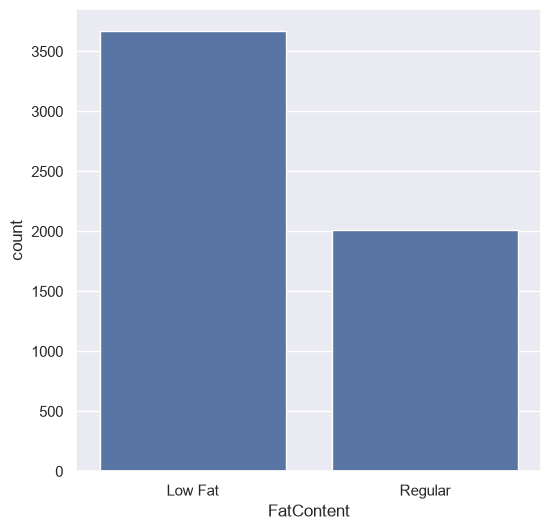

In [215]:
# FatContent
plt.figure(figsize = (6,6))
sns.countplot(x ='FatContent',data = big_mart_test)
plt.show()


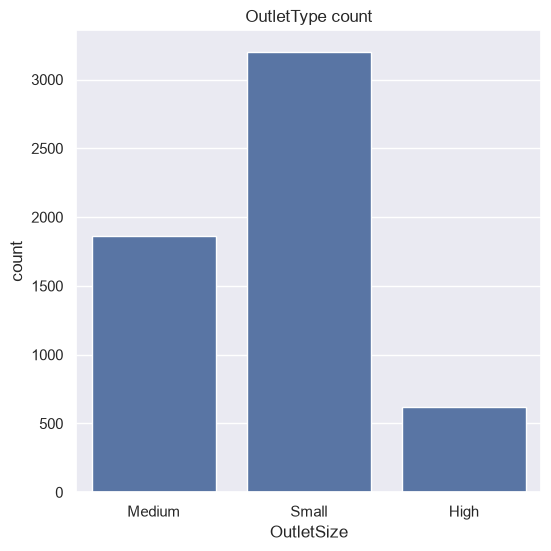

In [216]:
# OutletSize
plt.figure(figsize = (6,6))
sns.countplot(x ='OutletSize',data = big_mart_test)
plt.title('OutletType count')
plt.show()

### 8.9 Preparação Final para Predição

Encodamos as variáveis categóricas do conjunto de teste para que o modelo possa consumir os dados corretamente.

Label Encoder

In [ ]:
# Aplicamos o mesmo processo de encoding ao conjunto de teste
encoder = LabelEncoder()
big_mart_test['FatContent'] = encoder.fit_transform(big_mart_test['FatContent'])
big_mart_test['ProductType'] = encoder.fit_transform(big_mart_test['ProductType'])
big_mart_test['OutletSize'] = encoder.fit_transform(big_mart_test['OutletSize'])
big_mart_test['LocationType'] = encoder.fit_transform(big_mart_test['LocationType'])
big_mart_test['OutletType'] = encoder.fit_transform(big_mart_test['OutletType'])
big_mart_test['OutletID'] = encoder.fit_transform(big_mart_test['OutletID'])
big_mart_test['ProductID'] = encoder.fit_transform(big_mart_test['ProductID'])

In [218]:
big_mart_test.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType
0,1103,20.750,0,0.007565,13,107.8622,9,1999,1,0,1
1,1067,8.300,1,0.038428,4,87.3198,2,2007,2,1,1
2,1406,14.600,0,0.099575,11,241.7538,0,1998,2,2,0
3,809,7.315,0,0.015388,13,155.0340,2,2007,2,1,1
4,1184,13.600,1,0.118599,4,234.2300,5,1985,1,2,3


### 8.10 Geração das Previsões

Treinamos o modelo novamente com os dados completos e geramos as previsões para o arquivo final.

In [ ]:
# Refit do modelo com a base completa e geração das previsões para o conjunto de teste
model.fit(x, y)
test_predictions = model.predict(big_mart_test)
print(test_predictions)

[1620.8431  1329.9619   679.08356 ... 1938.6405  3895.5657  1332.872  ]


In [ ]:
# Convertendo o array de previsões em um DataFrame
OutletSales = test_predictions
df = pd.DataFrame(OutletSales, columns=['OutletSales'])

In [ ]:
# Adicionando as previsões ao DataFrame de teste
big_mart_test['OutletSales'] = OutletSales
big_mart_test.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType,OutletSales
0,1103,20.750,0,0.007565,13,107.8622,9,1999,1,0,1,1620.843140
1,1067,8.300,1,0.038428,4,87.3198,2,2007,2,1,1,1329.961914
2,1406,14.600,0,0.099575,11,241.7538,0,1998,2,2,0,679.083557
3,809,7.315,0,0.015388,13,155.0340,2,2007,2,1,1,2414.987061
4,1184,13.600,1,0.118599,4,234.2300,5,1985,1,2,3,6577.853516


In [ ]:
# Salvando as previsões em um arquivo CSV para uso posterior
big_mart_test.to_csv("db/big_mart_data_predictions.csv")